# 5. K-Nearest Neighbors

The one model here that does not learn a function at all.

KNN stores the training days and, to predict a new one, finds the k most similar
days in weather-space and averages their AQI. It is the closest thing in this
lineup to how a forecaster might reason by analogy: *this looks like a hot stagnant
September day, and those usually run around 120*.

It has one structural weakness worth watching. With 37 features, distances become
less discriminating — the curse of dimensionality — because everything ends up
roughly equidistant from everything else. It also cannot extrapolate: no
prediction can ever exceed the highest AQI in the training set, which matters for
the extreme days that are the most important ones to get right.

## Setup

Loads the shared split written by `notebooks/build_modeling_dataset.ipynb`.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, evaluate, diagnostic_plots, RANDOM_STATE, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()

print(f"train: {X_train.shape}  {meta['train_range'][0]} -> {meta['train_range'][1]}")
print(f"test:  {X_test.shape}  {meta['test_range'][0]} -> {meta['test_range'][1]}")
print(f"target: {meta['target']}  |  {meta['n_features']} features")

train: (2554, 37)  2016-01-04 -> 2022-12-31
test:  (1095, 37)  2023-01-01 -> 2025-12-30
target: daily_aqi  |  37 features


## Tuning on the training set only

Hyperparameters are chosen with `TimeSeriesSplit` cross-validation **inside the
training years**, never touching 2023–2025. Ordinary k-fold would shuffle the
calendar and let each fold train on days that come after its validation days;
`TimeSeriesSplit` always validates on a window that follows its training window,
which is the same forward-in-time question the final test asks.

Scaling is not optional here for the same reason as SVR — KNN is *entirely*
distance, so unit differences would decide the neighbours outright. The scaler sits
inside the pipeline so each CV fold standardizes on its own training data only.

In [2]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

MODEL_NAME = 'KNN'
tscv = TimeSeriesSplit(n_splits=5)

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', KNeighborsRegressor()),
])

grid = {
    'model__n_neighbors': [5, 10, 15, 25, 40, 60],
    'model__weights':     ['uniform', 'distance'],
    'model__p':           [1, 2],       # 1 = Manhattan, 2 = Euclidean
}

search = GridSearchCV(pipe, grid, cv=tscv,
                      scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

best = search.best_estimator_
print(f'\nbest params: {search.best_params_}')
print(f'best CV RMSE: {-search.best_score_:.3f}\n')

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params=search.best_params_,
                  notes=f'StandardScaler pipeline, GridSearchCV over {len(search.cv_results_["params"])} combos')

Fitting 5 folds for each of 24 candidates, totalling 120 fits



best params: {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'distance'}
best CV RMSE: 23.129

=== KNN ===
metric           train      test
RMSE             0.000    21.887
MAE              0.000    15.712
R2               1.000     0.706
MAPE %           0.000    18.684
within10 %     100.000    45.662

overfit gap (test RMSE - train RMSE): +21.887
saved -> models/results/knn.json


## Diagnostics

Three views of the same test predictions: how they line up against
truth, whether the errors are patterned or random, and how the model tracks the
actual 2023–2025 series day by day.

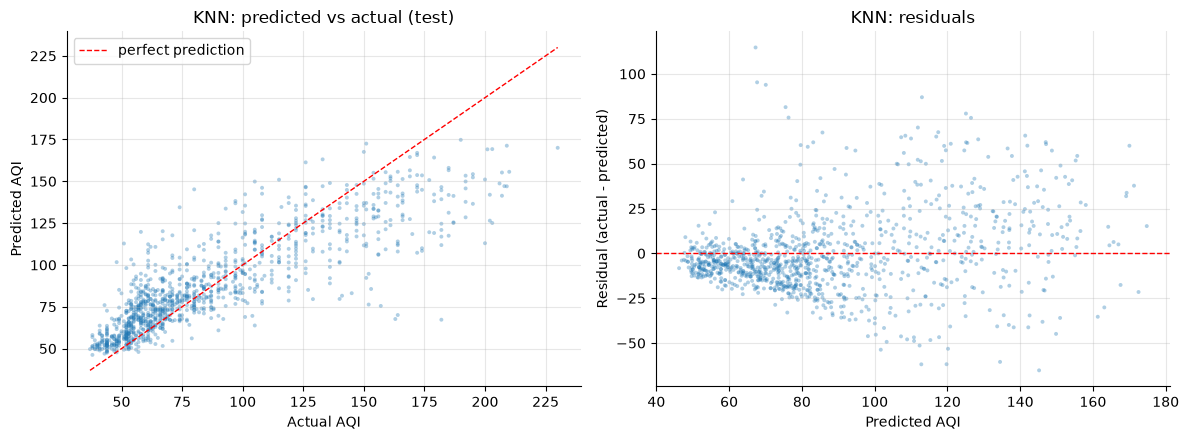

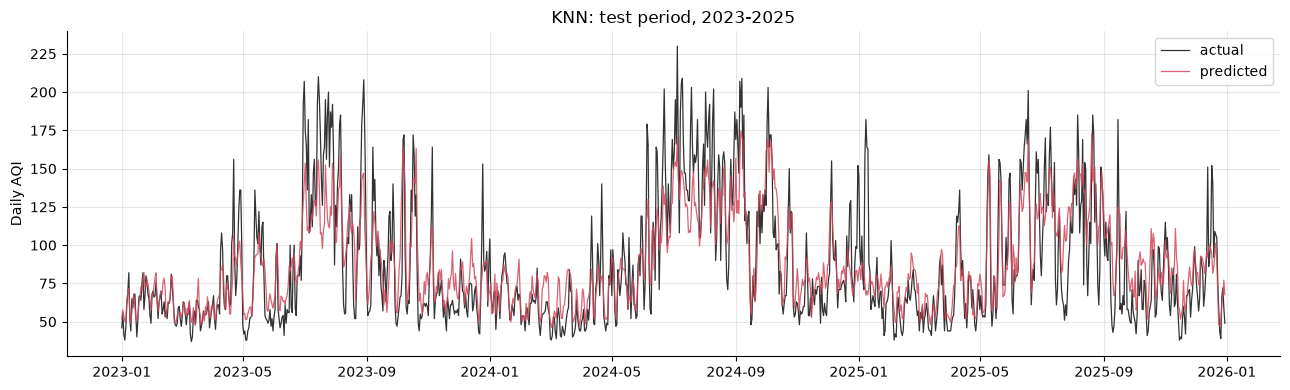

In [3]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## Checking the extrapolation ceiling

KNN averages observed AQI values, so its predictions are structurally trapped
inside the range of the training data — and averaging pulls them well inside it.
This compares the spread of its predictions against the actual test spread.

In [4]:
pred = best.predict(X_test)
print(f'{"":16}{"min":>8}{"max":>8}{"std":>8}')
print(f'{"train actual":16}{y_train.min():>8.1f}{y_train.max():>8.1f}{y_train.std():>8.1f}')
print(f'{"test actual":16}{y_test.min():>8.1f}{y_test.max():>8.1f}{y_test.std():>8.1f}')
print(f'{"test predicted":16}{pred.min():>8.1f}{pred.max():>8.1f}{pred.std():>8.1f}')

high = np.asarray(y_test) > 150
if high.sum():
    print(f'\nOn the {high.sum()} test days above AQI 150:')
    print(f'  mean actual:    {np.asarray(y_test)[high].mean():.1f}')
    print(f'  mean predicted: {pred[high].mean():.1f}')
    print(f'  mean shortfall: {(np.asarray(y_test)[high] - pred[high]).mean():.1f} AQI points')

                     min     max     std
train actual        31.0   250.0    37.0
test actual         37.0   230.0    40.4
test predicted      46.2   174.8    28.7

On the 122 test days above AQI 150:
  mean actual:    173.0
  mean predicted: 134.3
  mean shortfall: 38.7 AQI points


## What this told us

**Test RMSE 21.9, R² 0.706** — better than linear regression, worse than every
other nonlinear model. Reasoning by analogy works, but not as well as fitting a
function.

**The train RMSE of exactly 0.000 is an artifact, not a result.** Tuning selected
`weights='distance'`, and a training point is its own nearest neighbour at distance
zero, which gets infinite weight — so the model reproduces every training label
perfectly by construction. It learned nothing to achieve that. The "overfit gap" of
+21.9 is meaningless for this model and should be ignored in the comparison table;
KNN's test score is its only real score.

**The extrapolation ceiling is the substantive finding.** Because predictions are
weighted averages of observed AQI values, they are structurally trapped inside the
training range and averaging pulls them well inside it. Predicted test values span
46 to 175 with a standard deviation of 28.7, against actual values spanning 37 to
230 with a standard deviation of 40.4 — the model systematically flattens the
series.

That flattening is worst exactly where it matters. **On the 122 test days above AQI
150 — the unhealthy days that trigger public advisories — KNN under-predicts by an
average of 38.7 points.** A day that actually hit 173 gets called at 134, which
moves it from "Unhealthy" into the category below. For an air-quality warning
system that is the most costly error available, and it is a structural property of
the algorithm rather than something more tuning would fix.